In [1]:
# Importing essential libraries for data loading, cleaning, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv(r"F:\netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# ============================
# 📌 EDA Quality Check Template
# ============================

print("🔍 Basic Dataset Overview")
print("-" * 40)

# 1) Shape + Info
print("\n📏 Shape (Rows, Columns):")
print(df.shape)

print("\nℹ️ Data Types & Null Info:")
print(df.info())

# 2) Missing Values
print("\n❗ Missing Values Count:")
print(df.isnull().sum())

print("\n❗ Missing Values Percentage:")
print((df.isnull().mean() * 100).round(2))

# 3) Duplicates
print("\n📑 Number of Duplicated Rows:")
print(df.duplicated().sum())

# 4) Descriptive Stats (for numeric columns)
print("\n📊 Descriptive Statistics:")
print(df.describe(include='all'))

# 5) Unique Values (for categorical columns)
print("\n🔠 Unique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


🔍 Basic Dataset Overview
----------------------------------------

📏 Shape (Rows, Columns):
(8807, 12)

ℹ️ Data Types & Null Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

❗ Missing Values Count:
show_id            0
type               0
title              0
director        2634
cast   

In [4]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month



In [5]:
df['release_year'].describe()
#سليم مفيش اي قسم تحسها برا السياق 

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [6]:
# تحويل عمود date_added من نص (object) إلى تاريخ (datetime)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [7]:
# ================================
# فصل البيانات حسب نوع العمل
# Movies  → لاستخراج مدة الفيلم بالدقائق
# TV Shows → لاستخراج عدد المواسم
# ثم تحويل عمود duration من نص يحتوي على كلمات إلى رقم فقط باستخدام Regex
# ================================
movies = df[df['type'] == 'Movie']
shows  = df[df['type'] == 'TV Show']

movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)
shows['duration_int']  = shows['duration'].str.extract('(\d+)').astype(float)

movies[['duration', 'duration_int']].head(10)



C:\Users\amira\AppData\Local\Temp\ipykernel_23816\1003890459.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)
C:\Users\amira\AppData\Local\Temp\ipykernel_23816\1003890459.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows['duration_int']  = shows['duration'].str.extract('(\d+)').astype(float)


,duration,duration_int
0,90 min,90.0
6,91 min,91.0
7,125 min,125.0
9,104 min,104.0
12,127 min,127.0
13,91 min,91.0
16,67 min,67.0
18,94 min,94.0
22,161 min,161.0
23,61 min,61.0


In [8]:
# معالجة القيم الناقصة
df['director'].fillna('Unknown')
df['cast'].fillna('Unknown')
df['country'].fillna('Not specified')
# نملأ القيم الناقصة بأكثر قيمة مكررة في العمود
df['rating'].fillna(df['rating'].mode()[0])
df['date_added'].fillna(df['date_added'].mode()[0])
df['duration'].fillna(df['duration'].mode()[0])


0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: object

In [9]:
# ============================
# 🔍 Basic Data Quality Check
# ============================

# 1) عرض أول 5 صفوف لفهم شكل البيانات
df.head()

# 2) معلومات كاملة عن الأعمدة وأنواع البيانات وعدد القيم غير الناقصة
df.info()

# 3) حساب عدد القيم الناقصة في كل عمود
df.isnull().sum()

# 4) حساب نسبة القيم الناقصة في كل عمود
(df.isnull().sum() / len(df)) * 100

# 5) التحقق من وجود صفوف مكررة
df.duplicated().sum()

# 6) عرض القيم الفريدة في الأعمدة المهمة (اختياري)
df['type'].unique()
df['rating'].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8709 non-null   float64       
 13  month_added   8709 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(10)
memory usage: 963.4+ KB


array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

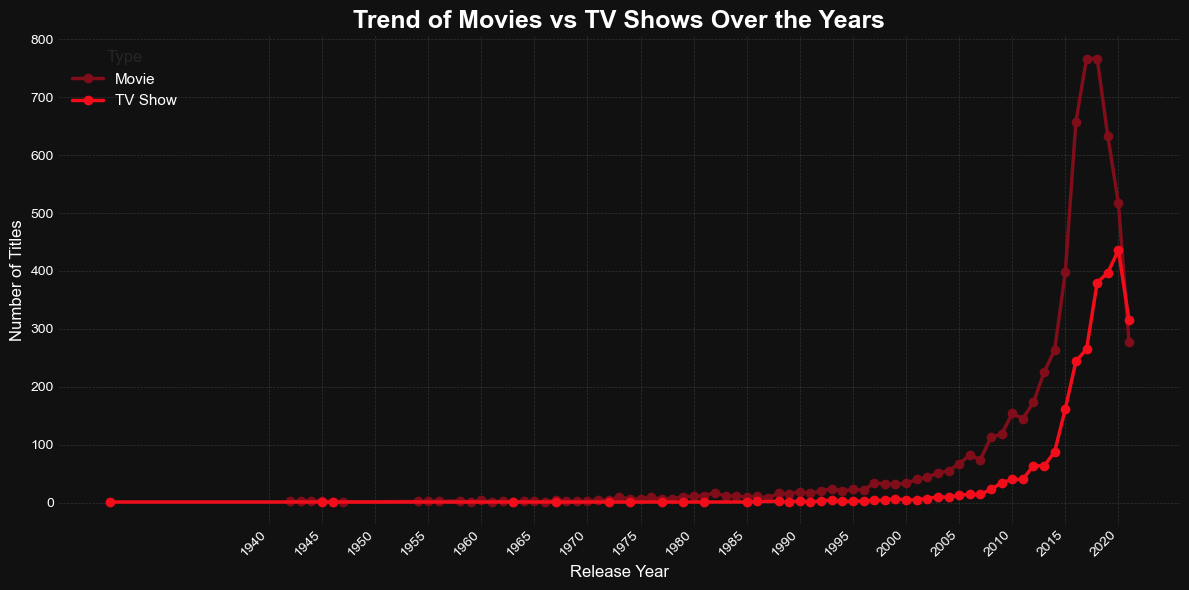

In [10]:
# Movies vs TV shows trend
trend = df.groupby(['type', 'release_year']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
plt.style.use('seaborn-v0_8-darkgrid')

types = trend['type'].unique()
type_means = trend.groupby('type')['count'].mean()
norm = (type_means - type_means.min()) / (type_means.max() - type_means.min())

colors = {
    t: (0.95 - n*0.45, 0.05, 0.1)
    for t, n in zip(type_means.index, norm)
}

for t in types:
    subset = trend[trend['type'] == t]
    plt.plot(
        subset['release_year'],
        subset['count'],
        marker='o',
        linewidth=2.5,
        color=colors[t],
        label=t
    )

plt.title('Trend of Movies vs TV Shows Over the Years',
          fontsize=18, fontweight='bold', color='white')

plt.xlabel('Release Year', fontsize=12, color='white')
plt.ylabel('Number of Titles', fontsize=12, color='white')

plt.xticks(range(1940, 2025, 5), rotation=45, ha='right', color='white')
plt.yticks(color='white')

plt.legend(title='Type', title_fontsize=12, fontsize=11,
           facecolor='#111111', edgecolor='white', labelcolor='white')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.gca().set_facecolor('#111111')
plt.gcf().patch.set_facecolor('#111111')

plt.tight_layout()
plt.show()


#### 📄 لماذا ارتفع إنتاج المسلسلات على Netflix؟

يوضّح الرسم الاتجاه الزمني لإنتاج الأفلام والمسلسلات على Netflix.  
نلاحظ أن عدد الأفلام مازال أعلى من عدد المسلسلات عبر معظم السنين،  
لكن ابتداءً من عام **2017** بدأ إنتاج المسلسلات يرتفع بشكل واضح.  

هذا الارتفاع يشير إلى **تحول استراتيجي** من Netflix نحو المحتوى الطويل،  
حيث أن المسلسلات تساعد على **زيادة وقت المشاهدة** و**الاحتفاظ بالمشتركين**.

**الأسباب المحتملة لهذا التحول:**
- المسلسلات تجذب المشاهد لفترة أطول مقارنة بالأفلام.  
- سهولة إنتاج مواسم جديدة مقارنة بإنتاج فيلم كامل.  
- الطلب العالمي المتزايد على المحتوى المتسلسل بعد 2017.  
- نجاح الأعمال غير الإنجليزية شجع Netflix على التوسع في إنتاج المسلسلات.  

**النتيجة:**  
رغم أن الأفلام مازالت الأكثر عددًا، إلا أن النمو السريع للمسلسلات  
يعكس **تغييرًا واضحًا في استراتيجية Netflix** خلال السنوات الأخيرة.


C:\Users\amira\AppData\Local\Temp\ipykernel_23816\2382180572.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_15.index, x=top_15.values, palette=colors)


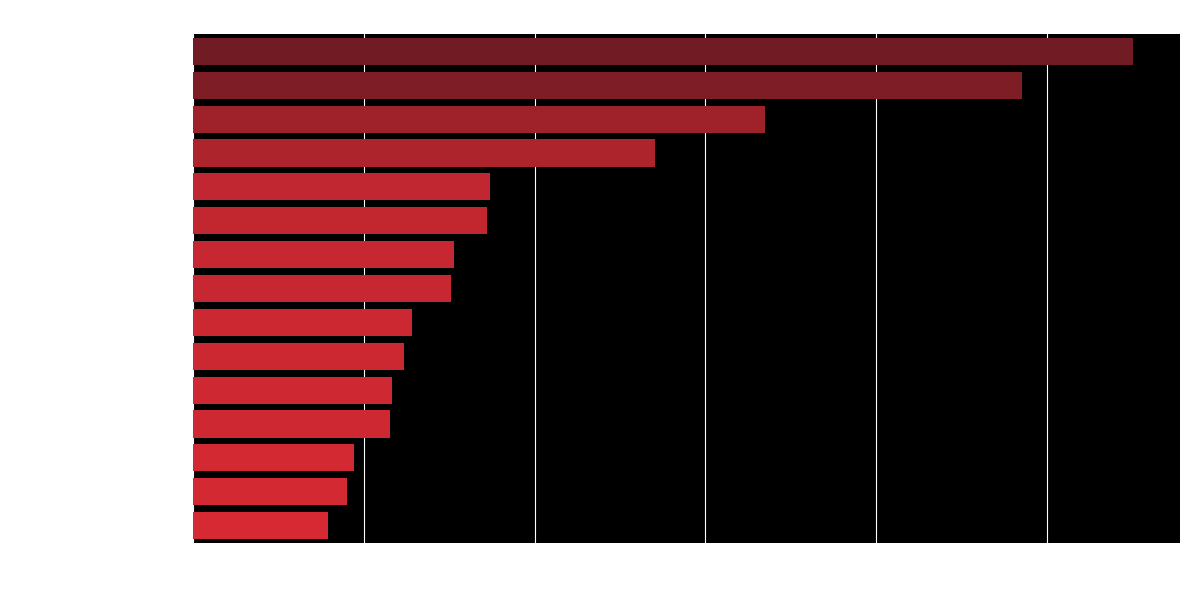

In [11]:
# Top 15 Netflix genres
df_exploded = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in').reset_index(drop=True)
top_15 = df_exploded['listed_in'].value_counts().head(15)

plt.figure(figsize=(12,6))  # وسّع العرض علشان البارات تبان كاملة
plt.style.use('dark_background')

# Normalize values for color gradient
norm = (top_15 - top_15.min()) / (top_15.max() - top_15.min())
colors = [(0.95 - n*0.45, 0.05, 0.1) for n in norm]

sns.barplot(y=top_15.index, x=top_15.values, palette=colors)

plt.title("Top 15 Genres on Netflix", fontsize=16, fontweight='bold', color='white')
plt.xlabel("Count", fontsize=12, color='white')
plt.ylabel("Genre", fontsize=12, color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.subplots_adjust(left=0.25, right=0.95)  # يمنع التآكل من الأطراف
plt.tight_layout()
plt.show()


# 🎬 Top Genres on Netflix

## الفكرة العامة
بعد فصل الأنواع داخل عمود listed_in وتحويل كل Genre لصف مستقل، ظهر توزيع واضح لأكتر أنواع المحتوى انتشارًا على Netflix.

## 🔍 الملخص
النتائج بتوضح إن Netflix بتركّز بشكل كبير على المحتوى الدرامي والوثائقي، مع وجود حضور قوي لأنواع ترفيهية خفيفة زي الكوميديا وبرامج الأطفال.

## 📌 أهم الملاحظات
- **Dramas** هي النوع الأكثر انتشارًا على المنصة، وده يعكس اعتماد Netflix الكبير على المحتوى القصصي الطويل.
- **International TV Shows** و **Documentaries** جايين في مراكز متقدمة، وده يوضح اهتمام Netflix بالمحتوى العالمي والواقعي.
- **Comedies** و **Kids' TV** موجودين بقوة، وده يشير إلى تنوع المحتوى واستهداف فئات عمرية مختلفة.
- وجود أنواع متخصصة زي **Crime TV Shows** و **Action & Adventure** بيدل على توسّع Netflix في المحتوى الموجّه لجمهور محدد.

## 🎯 النتيجة
توزيع الأنواع يوضح إن Netflix بتتبنّى استراتيجية "تنويع المحتوى" مع تركيز واضح على الدراما والوثائقيات، وده بيساعدها تجذب شرائح مختلفة من المشاهدين حول العالم.


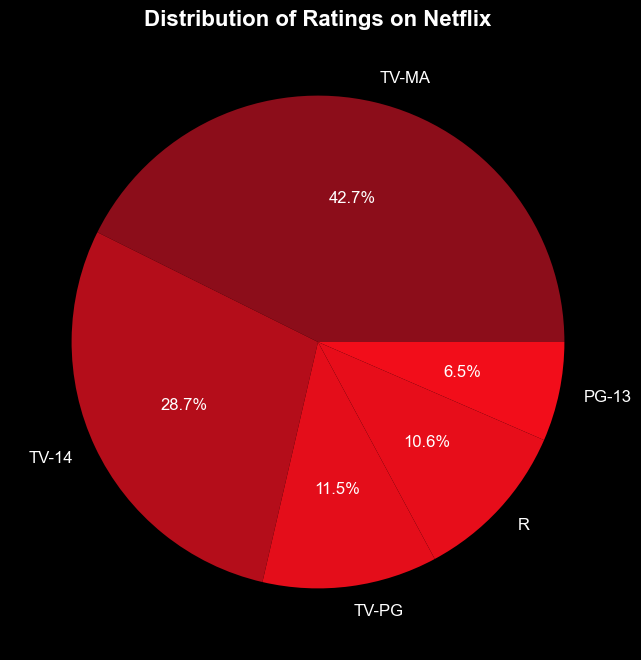

In [12]:
# Top 5 ratings pie chart
top_ratings = df['rating'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.style.use('dark_background')

norm = (top_ratings - top_ratings.min()) / (top_ratings.max() - top_ratings.min())
colors = [(0.95 - n*0.4, 0.05, 0.1) for n in norm]

plt.pie(
    top_ratings,
    labels=top_ratings.index,
    autopct='%1.1f%%',
    colors=colors,
    textprops={'color': 'white', 'fontsize': 12}
)

plt.title('Distribution of Ratings on Netflix', fontsize=16, fontweight='bold', color='white')
plt.ylabel('')
plt.show()


# 🎬 Top 5 Ratings on Netflix

## الفكرة العامة
التحليل بيعرض أعلى خمس تصنيفات مشاهدة (Ratings) على Netflix، وده بيوضح نوع الجمهور الأساسي اللي المنصة بتستهدفه.

## 🔍 الملخص
النتائج بتوضح إن Netflix بتركّز بشكل كبير على المحتوى الموجّه للكبار، مع وجود نسبة معتبرة من المحتوى المناسب للمراهقين والعائلات.

## 📌 أهم الملاحظات
- **TV-MA** هو التصنيف المسيطر بنسبة حوالي 43%، وده معناه إن أغلب المحتوى موجّه للبالغين.  
- **TV-14** بيجي في المركز التاني بنسبة تقارب 29%، وده بيوضح اهتمام Netflix بالمراهقين.  
- **TV-PG** و **PG-13** بيظهروا بنسب أقل، وده بيعكس إن المحتوى العائلي مش هو التركيز الأساسي.  
- **R** موجود بنسبة حوالي 10%، وده بيدل على وجود أفلام سينمائية للكبار ضمن المكتبة.

## 🎯 النتيجة
التحليل يوضح إن استراتيجية Netflix في المحتوى تميل بوضوح نحو الأعمال الموجهة للبالغين، مع الحفاظ على قدر محدود من التنوع لتغطية فئات عمرية مختلفة.


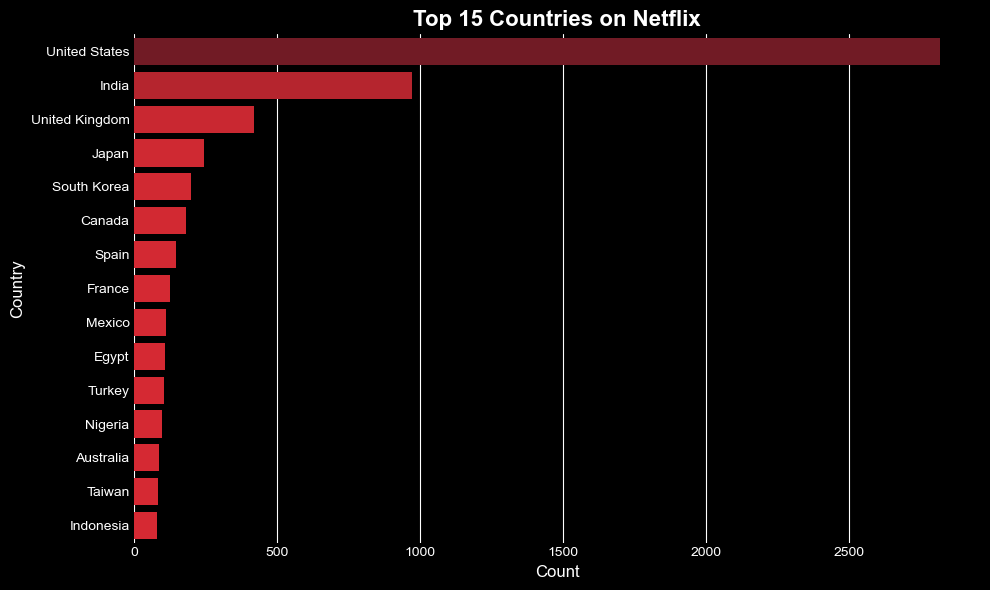

In [13]:
# Top 15 countries chart
top_15 = df['country'].value_counts().head(15)

plt.figure(figsize=(10,6))
plt.style.use('dark_background')

norm = (top_15 - top_15.min()) / (top_15.max() - top_15.min())
colors = [(0.95 - n*0.45, 0.05, 0.1) for n in norm]

sns.barplot(
    y=top_15.index,
    x=top_15.values,
    hue=top_15.index,
    palette=colors,
    legend=False
)

plt.title("Top 15 Countries on Netflix", fontsize=16, fontweight='bold', color='white')
plt.xlabel("Count", fontsize=12, color='white')
plt.ylabel("Country", fontsize=12, color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()


# 🌍 Top 15 Content-Producing Countries on Netflix

## الفكرة العامة
التحليل بيعرض أكتر الدول إنتاجًا للمحتوى على Netflix، وده بيوضح مدى انتشار المنصة عالميًا وتنوّع مصادر الإنتاج.

## 🔍 الملخص
النتائج بتوضح إن الولايات المتحدة هي المصدر الرئيسي للمحتوى، مع وجود قوي للهند والمملكة المتحدة، وظهور متزايد للدول الآسيوية والعربية.

## 📌 أهم الملاحظات
- **United States** هي الدولة المسيطرة بوضوح، وده طبيعي لأن أغلب إنتاج Netflix الأصلي بيتم هناك.  
- **India** في المركز التاني، وده بيعكس توسّع Netflix في السوق الآسيوي بشكل كبير.  
- **United Kingdom** و **Japan** و **South Korea** بيظهروا بقوة، وده بيدل على انتشار الإنتاج العالمي وتنوّع الثقافات.  
- وجود دول أوروبية زي **France** و **Spain** بيؤكد إن Netflix بتستثمر في المحتوى الأوروبي.  
- ظهور **Egypt** ضمن الـTop 15 بيدل على وجود محتوى عربي محدود لكنه موجود فعلاً ضمن مكتبة Netflix.

## 🎯 النتيجة
التحليل يوضح إن Netflix بتتبنّى استراتيجية إنتاج عالمية، لكن مع تركيز واضح على السوق الأمريكي والآسيوي، وده بيساعدها تجذب جمهور متنوّع حول العالم.


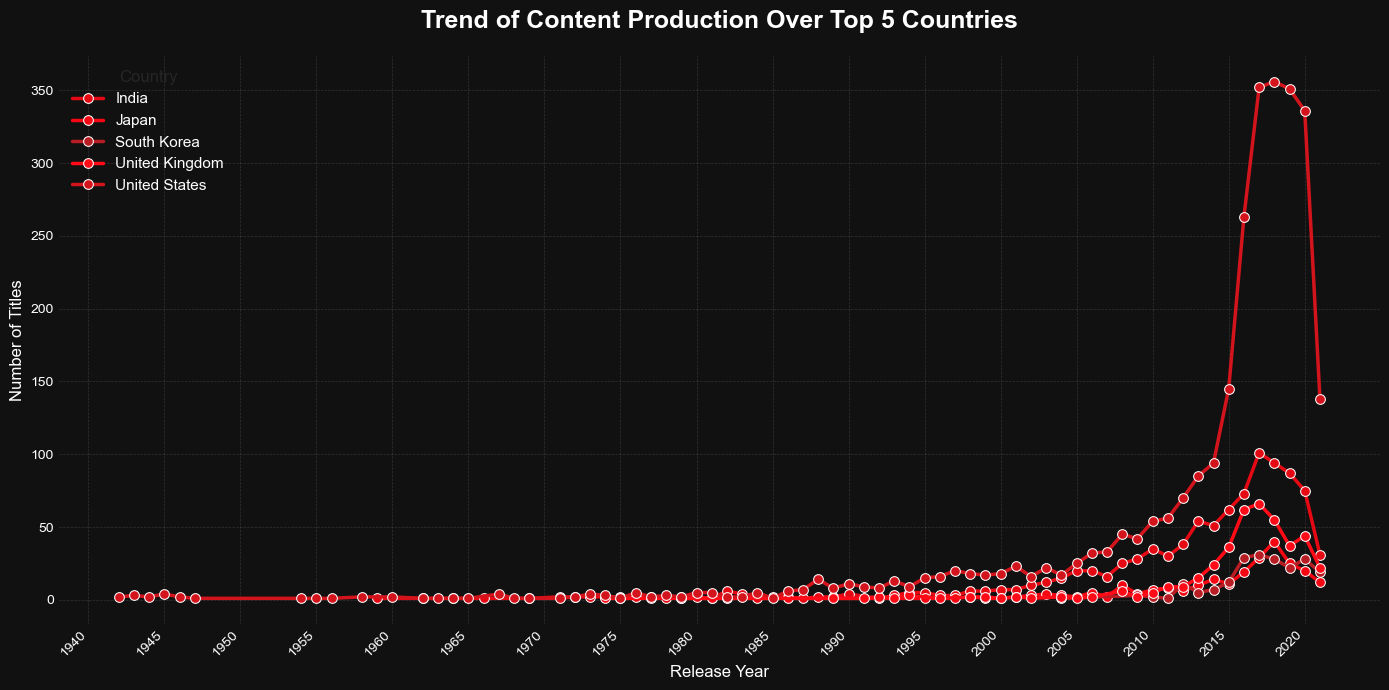

In [14]:
# Top 5 countries trend
country_trend = df.groupby(['country', 'release_year']).size().reset_index(name='count')

top_5_countries = (
    country_trend.groupby('country')['count']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_5_trend = country_trend[country_trend['country'].isin(top_5_countries)]

plt.figure(figsize=(14, 7))
plt.style.use('seaborn-v0_8-darkgrid')

netflix_palette = ['#E50914', '#F40612', '#B81D24', '#FF0A16', '#D4141C']

sns.lineplot(
    data=top_5_trend,
    x='release_year',
    y='count',
    hue='country',
    palette=netflix_palette,
    marker='o',
    linewidth=2.5,
    markersize=7
)

plt.title(
    'Trend of Content Production Over Top 5 Countries',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=20
)

plt.xlabel('Release Year', fontsize=12, color='white')
plt.ylabel('Number of Titles', fontsize=12, color='white')

plt.xticks(range(1940, 2025, 5), rotation=45, ha='right', color='white')
plt.yticks(color='white')

plt.gca().set_facecolor('#111111')
plt.gcf().patch.set_facecolor('#111111')

plt.legend(title='Country', title_fontsize=12, fontsize=11,
           facecolor='#111111', edgecolor='white', labelcolor='white')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()


# 📈 Release Year Trends for Top 5 Countries on Netflix

## الفكرة العامة
التحليل بيعرض تطوّر إنتاج المحتوى عبر السنين لأكبر خمس دول منتجة على Netflix، وده بيوضح اتجاهات النمو العالمي في صناعة الأفلام والمسلسلات.

## 🔍 الملخص
النتائج بتوضح إن الولايات المتحدة كانت وما زالت المصدر الرئيسي للمحتوى، مع نمو واضح في الهند وكوريا الجنوبية خلال السنوات الأخيرة، بينما اليابان والمملكة المتحدة حافظوا على إنتاج مستقر.

## 📌 أهم الملاحظات
- **United States** هي الدولة المسيطرة بوضوح، وبتشهد زيادة ضخمة بعد 2010 بسبب توسّع إنتاج Netflix Originals.  
- **India** شهدت طفرة قوية بعد 2017، وده بيعكس دخول Netflix بقوة في السوق الهندي.  
- **South Korea** بدأت في الصعود الحاد بعد 2019، وده متوافق مع الانتشار العالمي للأعمال الكورية.  
- **United Kingdom** إنتاجها ثابت لكن أقل من أمريكا والهند.  
- **Japan** إنتاجها مستقر نسبيًا بدون تغيّرات كبيرة.

## 🎯 النتيجة
التحليل يوضح إن Netflix بتتوسع عالميًا، لكن النمو الحقيقي في السنوات الأخيرة جاي من آسيا، خصوصًا الهند وكوريا، بينما تظل الولايات المتحدة هي المحور الأساسي للإنتاج.


C:\Users\amira\AppData\Local\Temp\ipykernel_23816\3473756663.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


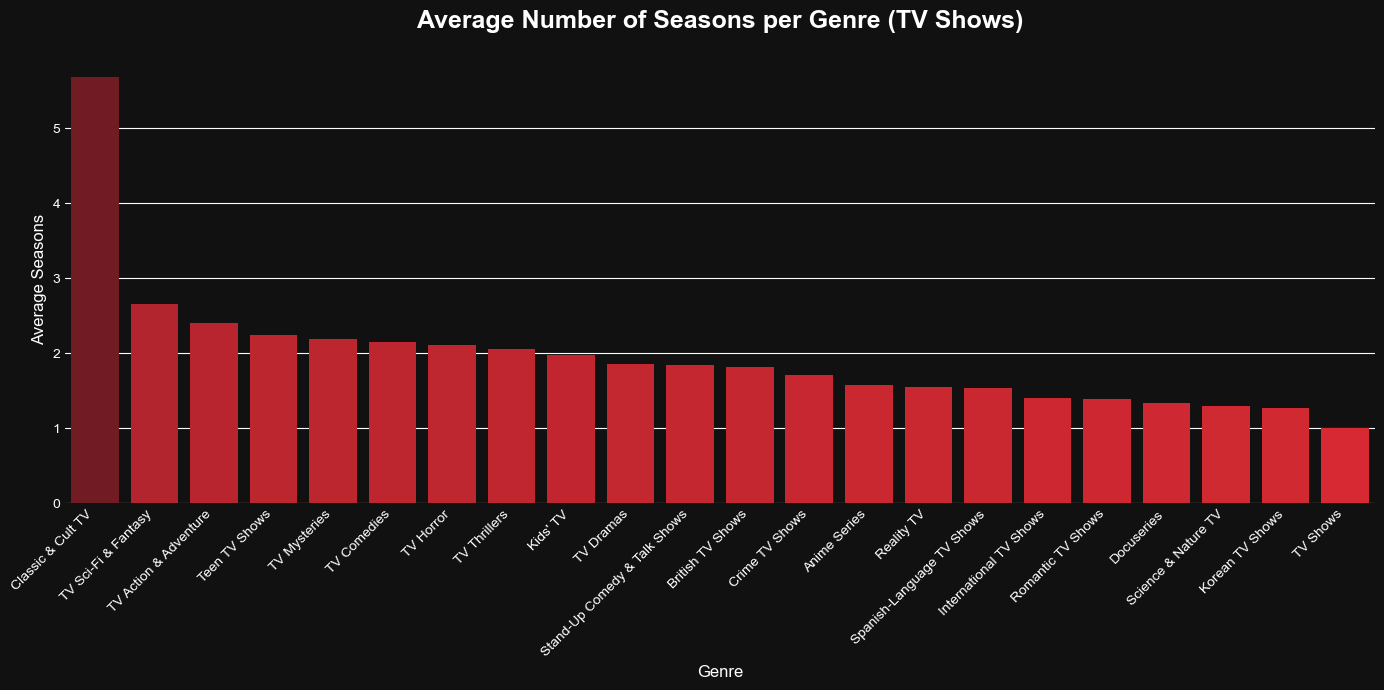

In [15]:
# Average seasons per genre (TV shows)
df_exploded = df_exploded[df_exploded['type'] == 'TV Show'].copy()
df_exploded['seasons'] = df_exploded['duration'].str.extract(r'(\d+)').astype(int)

genre_seasons = (
    df_exploded.groupby('listed_in')['seasons']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))
plt.style.use('seaborn-v0_8-darkgrid')

norm = (genre_seasons - genre_seasons.min()) / (genre_seasons.max() - genre_seasons.min())
colors = [(0.95 - n*0.45, 0.05, 0.1) for n in norm]

sns.barplot(
    x=genre_seasons.index,
    y=genre_seasons.values,
    palette=colors
)

plt.title(
    'Average Number of Seasons per Genre (TV Shows)',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=20
)

plt.xlabel('Genre', fontsize=12, color='white')
plt.ylabel('Average Seasons', fontsize=12, color='white')

plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')

plt.gca().set_facecolor('#111111')
plt.gcf().patch.set_facecolor('#111111')

sns.despine()
plt.tight_layout()
plt.show()


### 📌 Insight: Average Seasons per Genre (TV Shows)

يوضّح التحليل إن بعض الأنواع على نتفليكس بتميل لعدد مواسم أعلى من غيرها، وده بيعكس طبيعة المحتوى وطول عمره الإنتاجي:

- **Classic & Cult TV** بيحقق أعلى متوسط مواسم، وده منطقي لأنه بيضم أعمال طويلة العمر.
- **Sci‑Fi & Fantasy** و **Action & Adventure** بييجوا بعده بسبب القصص الممتدة اللي بتحتاج مواسم متعددة.
- الأنواع زي **Documentaries** و **Korean TV Shows** غالبًا قصيرة ومحدودة المواسم.

النتيجة:  
**الـGenres اللي قصصها ممتدة أو جمهورها ثابت عبر السنين هي الأكثر إنتاجًا لمواسم متعددة.**


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 30 كلمات في الوصف بعد التنظيف:
young           -> 729
new             -> 709
family          -> 635
world           -> 570
man             -> 538
two             -> 505
love            -> 504
woman           -> 486
friends         -> 445
must            -> 398
documentary     -> 365
find            -> 341
school          -> 339
father          -> 317
home            -> 317
finds           -> 313
old             -> 310
three           -> 301
high            -> 299
help            -> 296
lives           -> 277
takes           -> 275
group           -> 266
years           -> 252
take            -> 240
girl            -> 239
back            -> 234
year            -> 234
city            -> 226
save            -> 222


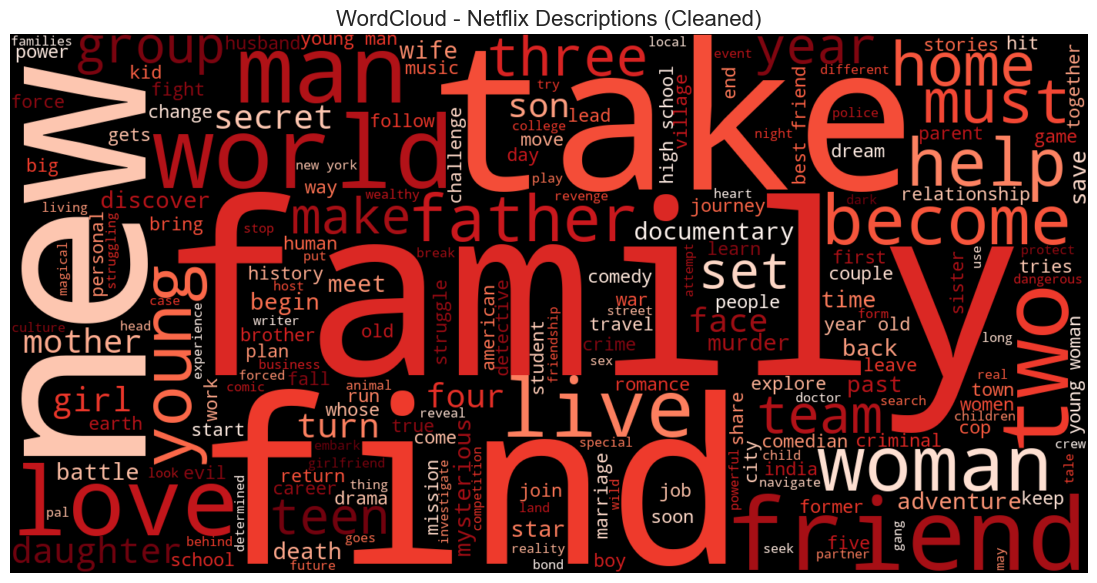


Top 30 Bigrams في الوصف:
high school               -> 145
year old                  -> 145
young woman               -> 111
young man                 -> 110
new york                  -> 98
small town                -> 66
best friend               -> 57
best friends              -> 54
world war                 -> 53
los angeles               -> 47
stand special             -> 47
documentary follows       -> 44
york city                 -> 41
falls love                -> 40
around world              -> 39
martial arts              -> 36
road trip                 -> 36
social media              -> 36
serial killer             -> 35
behind scenes             -> 33
two young                 -> 30
young boy                 -> 29
documentary explores      -> 28
fall love                 -> 28
hong kong                 -> 28
true events               -> 27
civil war                 -> 26
police officer            -> 26
young girl                -> 26
middle aged               -> 25


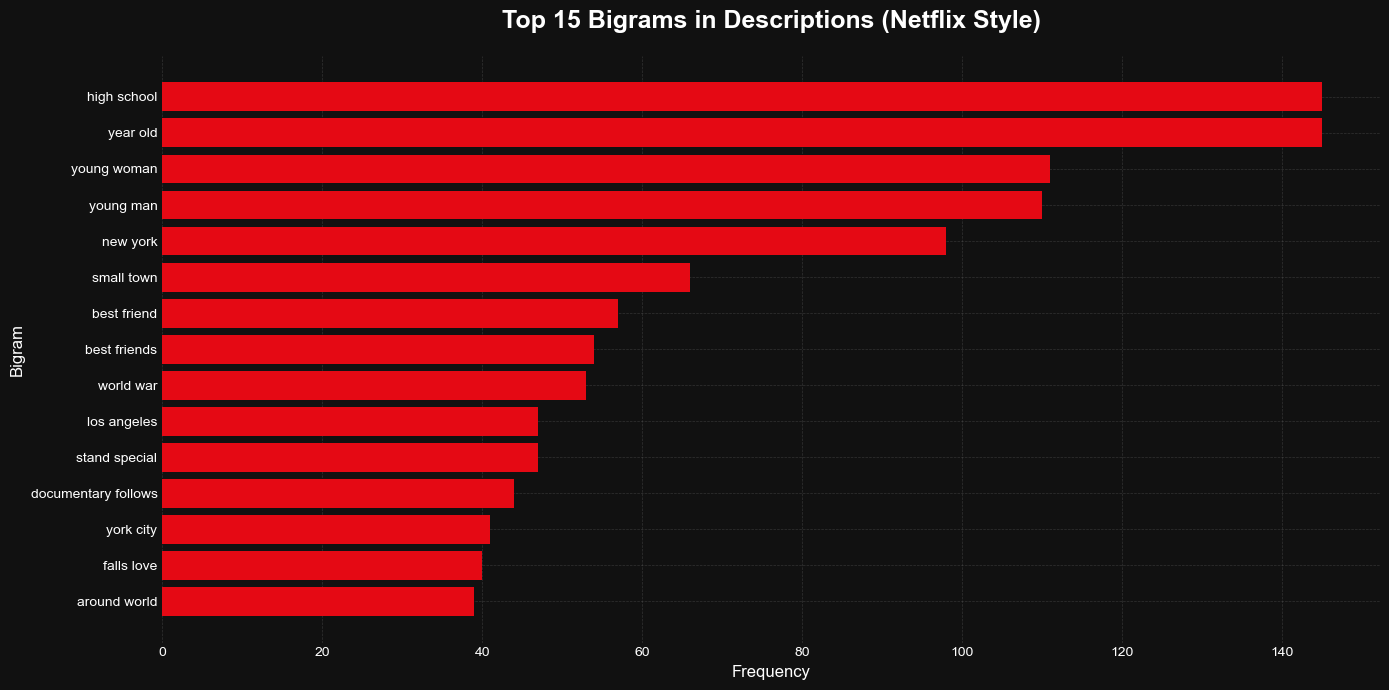

In [20]:
# Text cleaning, keywords, bigrams, and wordcloud
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords

from wordcloud import WordCloud
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
extra_stopwords = {'series', 'movie', 'story', 'netflix', 'film', 'show', 'based', 'life', 'one'}
stop_words = stop_words.union(extra_stopwords)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df['clean_desc'] = df['description'].apply(clean_text)

all_words = " ".join(df['clean_desc']).split()
word_freq = Counter(all_words).most_common(30)

print("Top 30 كلمات في الوصف بعد التنظيف:")
for word, freq in word_freq:
    print(f"{word:<15} -> {freq}")

text_for_wc = " ".join(df['clean_desc'])

wc = WordCloud(
    width=1400,
    height=700,
    background_color='black',
    colormap='Reds',
    max_words=200
).generate(text_for_wc)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Netflix Descriptions (Cleaned)", fontsize=16)
plt.show()

vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=30)
X = vectorizer.fit_transform(df['clean_desc'])

bigrams = vectorizer.get_feature_names_out()
bigram_counts = X.toarray().sum(axis=0)

bigram_freq = sorted(list(zip(bigrams, bigram_counts)), key=lambda x: x[1], reverse=True)

print("\nTop 30 Bigrams في الوصف:")
for bg, freq in bigram_freq:
    print(f"{bg:<25} -> {freq}")

# Netflix-style bigrams chart
top_n = 15
top_bigrams = bigram_freq[:top_n]

labels = [x[0] for x in top_bigrams]
values = [x[1] for x in top_bigrams]

plt.figure(figsize=(14,7))
plt.style.use('dark_background')

bar_color = '#E50914'

plt.barh(labels, values, color=bar_color)
plt.gca().invert_yaxis()

plt.title(
    "Top 15 Bigrams in Descriptions (Netflix Style)",
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=20
)

plt.xlabel("Frequency", fontsize=12, color='white')
plt.ylabel("Bigram", fontsize=12, color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.gca().set_facecolor('#111111')
plt.gcf().patch.set_facecolor('#111111')

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()


### 🔍 Text Analysis – What Netflix Focuses on in Content Descriptions

تحليل أوصاف المحتوى بعد التنظيف كشف أن Netflix بتركّز على Themes واضحة جدًا:

- الكلمات الأكثر تكرارًا بتدور حول **العلاقات الإنسانية**: young, family, man, woman, friends, love  
- في تركيز كبير على **السن والمراحل العمرية**: young, old, girl, boy  
- كلمات بتوحي بـ **الدراما اليومية**: home, school, father, city, years  
- وجود كلمة documentary ضمن الأعلى تكرارًا يعكس انتشار المحتوى الوثائقي على المنصّة

### 🔥 Bigrams – الجمل المتكررة اللي بتكشف طبيعة المحتوى

- **high school** و **young woman / young man** → محتوى مراهقين وشباب  
- **year old** → وصف شخصيات حسب العمر (نبرة وثائقية/درامية)  
- **small town**, **new york**, **los angeles**, **hong kong** → تركيز على مواقع جغرافية محددة  
- **serial killer**, **police officer**, **true events**, **civil war** → محتوى جريمة وقصص حقيقية  
- **documentary follows / documentary explores** → تأكيد على قوة المحتوى الوثائقي  
- **falls love / fall love** → محتوى رومانسي متكرر

### 🎯 الخلاصة

لغة وصف Netflix بتميل إلى:
- قصص **مراهقين وشباب**
- **دراما عائلية**
- **جريمة وتحقيقات**
- **وثائقيات عن أحداث حقيقية**
- **رومانسية خفيفة**

وده بيكمّل الصورة اللي شفناها في الـGenres وبيأكد إن Netflix بتستخدم لغة درامية، إنسانية، وقريبة من الحياة اليومية.


In [17]:
top_15.head(15)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Turkey             105
Nigeria             95
Australia           87
Taiwan              81
Indonesia           79
Name: count, dtype: int64

Top Genres: ['International Movies', 'Dramas', 'Comedies', 'International TV Shows', 'Documentaries']

Top words in genre: International Movies
young           -> 320
man             -> 303
woman           -> 257
family          -> 228
love            -> 228
two             -> 182
new             -> 166
father          -> 150
must            -> 139
find            -> 124
world           -> 123
finds           -> 119
three           -> 117
friends         -> 110
documentary     -> 110
years           -> 107
home            -> 104
son             -> 103
girl            -> 101
old             -> 98

Top words in genre: Dramas
young           -> 352
man             -> 249
family          -> 219
woman           -> 211
love            -> 207
new             -> 195
father          -> 164
two             -> 157
finds           -> 125
old             -> 115
must            -> 108
son             -> 107
mother          -> 104
find            -> 101
world           -> 99
lives           -> 95
hom

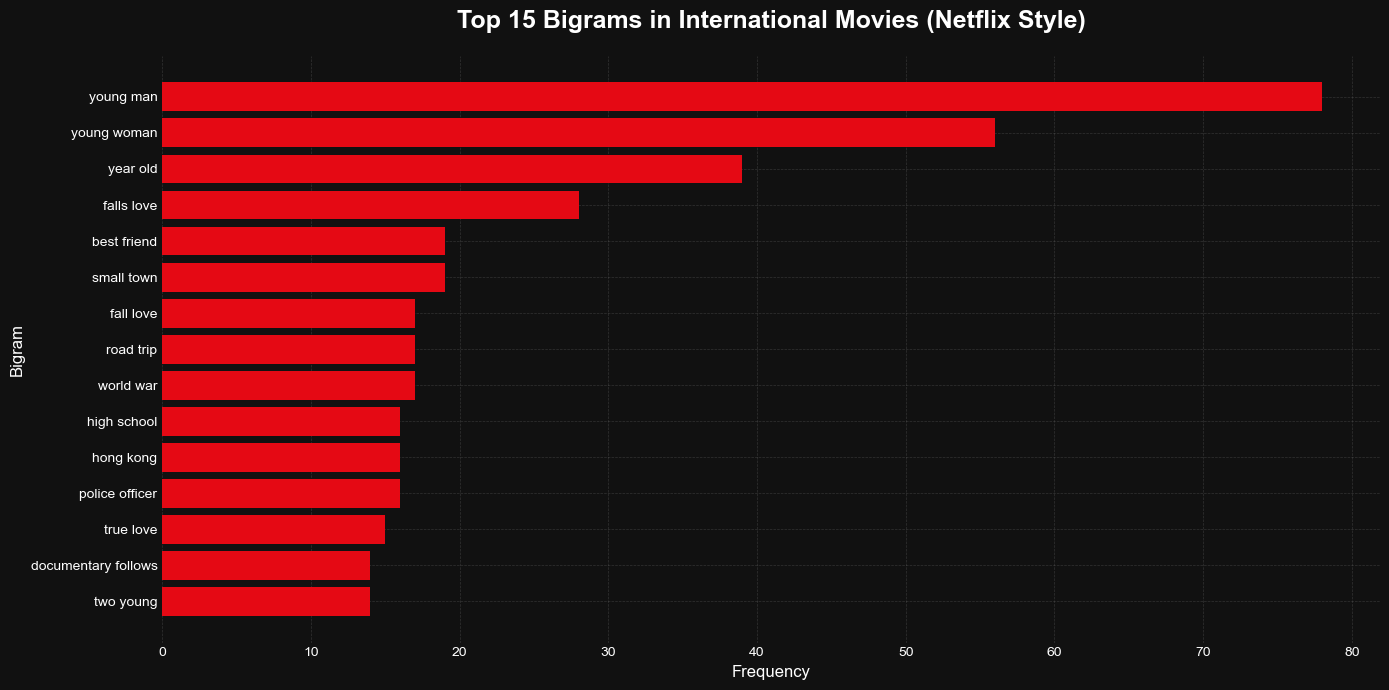

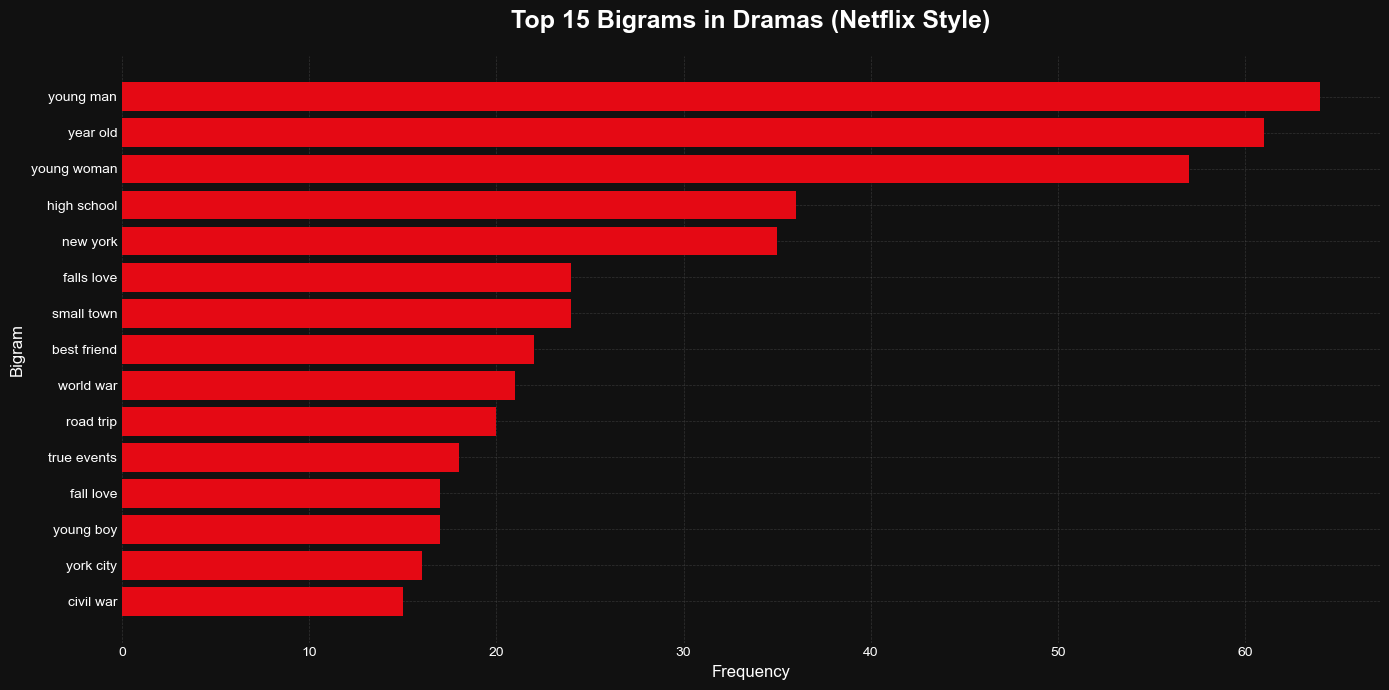

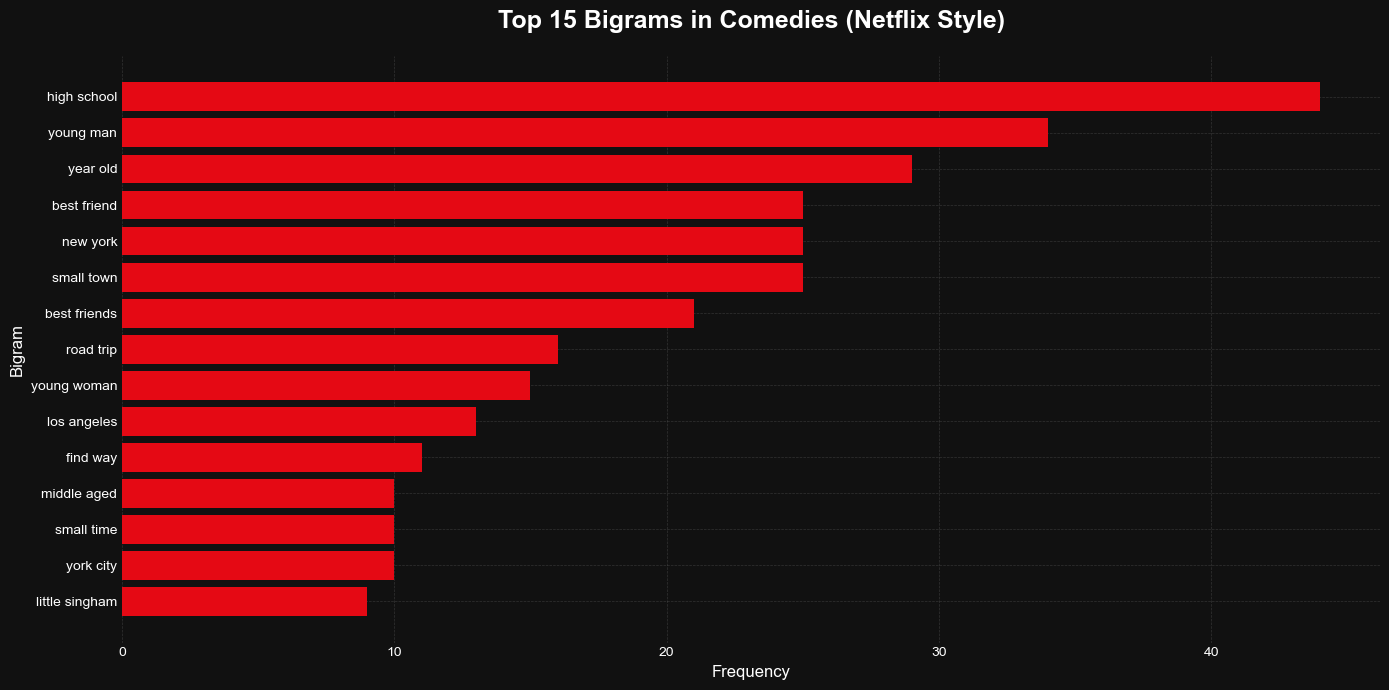

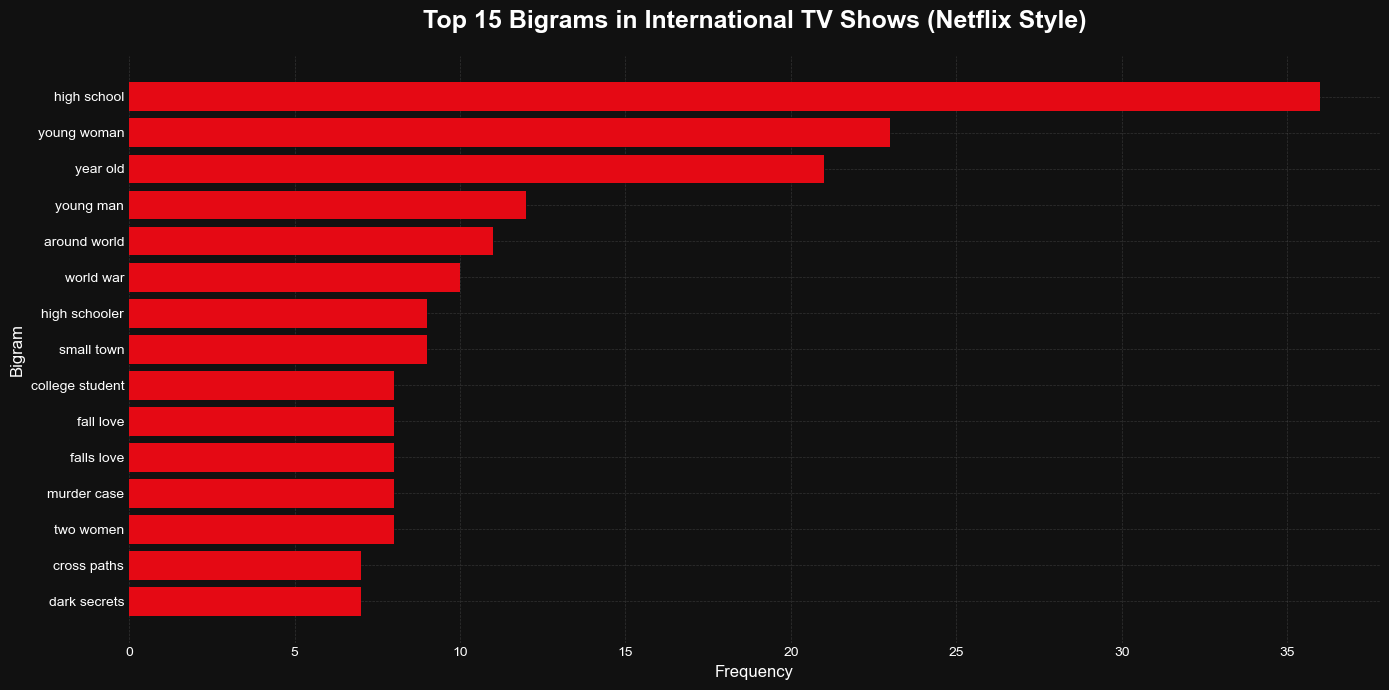

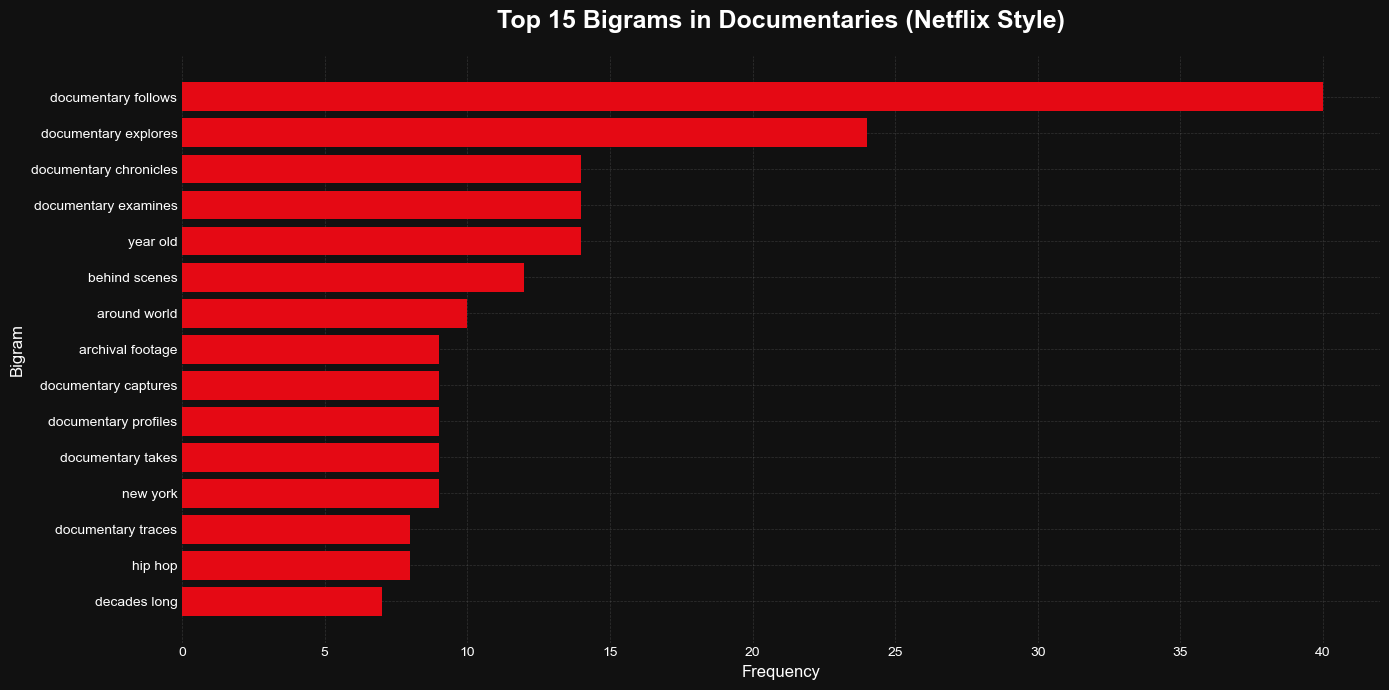

In [22]:
# Top words & bigrams per genre + Netflix-style charts
df['genre_list'] = df['listed_in'].str.split(',').apply(lambda x: [g.strip() for g in x])

df_exploded = df.explode('genre_list')
df_exploded = df_exploded.rename(columns={'genre_list': 'genre'})

top_genres = (
    df_exploded['genre']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top Genres:", top_genres)

from collections import Counter

def get_top_words_for_genre(df_genre, n=20):
    all_words = " ".join(df_genre['clean_desc']).split()
    return Counter(all_words).most_common(n)

genre_word_stats = {}
for g in top_genres:
    df_g = df_exploded[df_exploded['genre'] == g]
    genre_word_stats[g] = get_top_words_for_genre(df_g, n=20)

for g, words in genre_word_stats.items():
    print(f"\nTop words in genre: {g}")
    for w, c in words:
        print(f"{w:<15} -> {c}")

from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams_for_genre(df_genre, n=15):
    vectorizer = CountVectorizer(ngram_range=(2, 2))
    X = vectorizer.fit_transform(df_genre['clean_desc'])
    bigram_counts = X.sum(axis=0).A1
    bigram_names = vectorizer.get_feature_names_out()
    bigram_freq = sorted(list(zip(bigram_names, bigram_counts)), key=lambda x: x[1], reverse=True)
    return bigram_freq[:n]

genre_bigram_stats = {}
for g in top_genres:
    df_g = df_exploded[df_exploded['genre'] == g]
    genre_bigram_stats[g] = get_top_bigrams_for_genre(df_g, n=15)

    # ============================
    # Netflix-style chart per genre
    # ============================
    labels = [x[0] for x in genre_bigram_stats[g]]
    values = [x[1] for x in genre_bigram_stats[g]]

    plt.figure(figsize=(14,7))
    plt.style.use('dark_background')

    bar_color = '#E50914'

    plt.barh(labels, values, color=bar_color)
    plt.gca().invert_yaxis()

    plt.title(
        f"Top 15 Bigrams in {g} (Netflix Style)",
        fontsize=18,
        fontweight='bold',
        color='white',
        pad=20
    )

    plt.xlabel("Frequency", fontsize=12, color='white')
    plt.ylabel("Bigram", fontsize=12, color='white')

    plt.xticks(color='white')
    plt.yticks(color='white')

    plt.gca().set_facecolor('#111111')
    plt.gcf().patch.set_facecolor('#111111')

    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()


### 🎬 Insights – International Movies

**Top Words Analysis**
الكلمات الأكثر تكرارًا بتوضح إن المحتوى الدولي على Netflix بيركّز على:
- young, man, woman → قصص شبابية وشخصيات رئيسية واضحة
- family, love → دراما عائلية ورومانسية
- father, son, girl → علاقات أسرية متعددة الأجيال
- world, home, years → انتقالات، سفر، وتغيّر عبر الزمن

**Top Bigrams Analysis**
الجمل المكوّنة من كلمتين بتكشف Themes قوية:
- "young man", "young woman" → أبطال شباب في قلب القصة
- "year old" → وصف أعمار الشخصيات (نبرة درامية/واقعية)
- "falls love", "fall love", "love triangle" → رومانسية واضحة
- "serial killer", "police officer" → عناصر جريمة
- "world war", "hong kong" → سياقات دولية وتاريخية

**Overall Insight**
International Movies بتجمع بين:
- دراما عائلية  
- رومانسية  
- قصص شبابية  
- عناصر جريمة  
- سياقات تاريخية ودولية  

وده بيعكس تنوّع المحتوى الدولي على Netflix.


### 🎭 Insights – Dramas

**Top Words Analysis**
الكلمات الأكثر تكرارًا بتوضح إن الدراما على Netflix بتركّز على:
- young, man, woman → شخصيات محورية شابة
- family, father, mother, son → علاقات أسرية معقّدة
- love → عنصر رومانسي دائم
- school, home, world → سياقات يومية واقعية

**Top Bigrams Analysis**
- "young man", "young woman" → أبطال شباب
- "year old" → وصف أعمار (نبرة واقعية)
- "high school" → دراما مراهقين
- "small town", "new york", "los angeles" → خلفيات اجتماعية مختلفة
- "true events", "civil war", "world war" → ارتباط بالقصص الحقيقية

**Overall Insight**
الدراما على Netflix بتمزج بين:
- العلاقات الإنسانية  
- الصراعات الأسرية  
- قصص المراهقين  
- أحداث واقعية وتاريخية  


### 😂 Insights – Comedies

**Top Words Analysis**
الكلمات الأكثر تكرارًا بتوضح إن الكوميديا على Netflix بتركّز على:
- family, friends → علاقات اجتماعية خفيفة
- young, man, woman → شخصيات بسيطة وقريبة من الجمهور
- school, high → كوميديا مراهقين
- gets, help, find → مواقف يومية ومفارقات

**Top Bigrams Analysis**
- "high school" → كوميديا مراهقين
- "best friend", "best friends" → صداقات
- "small town", "new york" → مواقف اجتماعية
- "turned upside", "win back", "win heart" → حبكات كوميدية كلاسيكية

**Overall Insight**
الكوميديا على Netflix بتعتمد على:
- مواقف اجتماعية  
- صداقات  
- حياة مدرسية  
- قصص رومانسية خفيفة  


### 🌍 Insights – International TV Shows

**Top Words Analysis**
الكلمات الأكثر تكرارًا بتوضح إن المسلسلات الدولية بتركّز على:
- young, woman, man → شخصيات شبابية
- love, family → دراما اجتماعية
- school, high → محتوى مراهقين
- mysterious, group → عناصر غموض وتشويق

**Top Bigrams Analysis**
- "high school", "high schooler" → محتوى مراهقين
- "young woman", "young man" → أبطال شباب
- "around world", "world war" → سياقات عالمية
- "murder case", "drug lord", "drug trafficking" → جريمة وتشويق
- "cross paths", "dark secrets" → حبكات معقّدة

**Overall Insight**
International TV Shows بتمزج بين:
- دراما شبابية  
- غموض وتشويق  
- جريمة  
- سياقات عالمية  


### 🎥 Insights – Documentaries

**Top Words Analysis**
الكلمات الأكثر تكرارًا بتوضح إن الوثائقيات على Netflix بتركّز على:
- documentary, explores, examines, follows → لغة وثائقية مباشرة
- world, history, american → موضوعات عالمية وتاريخية
- interviews, footage → مواد أرشيفية وشهادات
- journey, career → قصص شخصية

**Top Bigrams Analysis**
- "documentary follows", "documentary explores", "documentary examines" → أسلوب سرد وثائقي واضح
- "behind scenes", "archival footage" → محتوى خلف الكواليس
- "year old" → قصص شخصية
- "hip hop", "rock band" → موضوعات موسيقية
- "award winning" → أعمال ذات جودة عالية

**Overall Insight**
Documentaries على Netflix بتركّز على:
- قصص حقيقية  
- شخصيات مؤثرة  
- أحداث تاريخية  
- محتوى أرشيفي  
